# Photometry with Fink API

This notebook shows how to access photometry using the Fink REST API (https://api.lsst.fink-portal.org), and display a lightcurve. For the definition of fields, we refer the reader to:

- Documentation: https://doc.lsst.fink-broker.org/data/photometry/
- Schema page: https://lsst.fink-portal.org/schemas/

In [1]:
import requests
import pandas as pd
import numpy as np
import io
import seaborn
seaborn.set_context("poster")

import matplotlib.pyplot as plt

In [2]:
UNIQUE_BANDS = ["u", "g", "r", "i", "z", "y"]
MARKERS = {
    "u": "o",
    "g": "<",
    "r": ">",
    "i": "s",
    "z": "*",
    "y": "p",
}

COLORS = {
    "u": "#15284f", 
    "g": "#626d84", 
    "r": "#afb2b9", 
    "i": "#dbbeb2", 
    "z": "#e89070", 
    "y": "#f5622e"
}

In [3]:
def plot_lightcurve_allbands(time, flux, fluxErr, bands, ax, label=""):
    """Wrapper to plot all filter bands"""
    for band in UNIQUE_BANDS:
        mask = bands == band
        if mask.sum() == 0:
            continue
        ax.errorbar(
            time[mask],
            flux[mask],
            fluxErr[mask],
            color=COLORS[band],
            marker=MARKERS[band],
            label=f"{band} band",
            ls=""
        )

def plot_lightcurve_singleband(time, flux, fluxErr, bands, ax, single_band, label="", color="C0", marker="o"):
    """Wrapper to plot a single band"""
    mask = bands == single_band
    if mask.sum() == 0:
        print(f"No data for band {single_band}")
        return
    ax.errorbar(
        time[mask],
        flux[mask],
        fluxErr[mask],
        color=color,
        marker=marker,
        label=label,
        ls=""
    )

def quad_error(*args):
    """Add input errors quadratically
    
    Parameters
    ----------
    args: pd.Series, or array-like

    Returns
    -------
    out: pd.Series, or array-like
        Vector of errors
    """
    return np.sqrt(np.sum([err**2 for err in args], axis=0))

## Photometry

Let's download data for an object, and display its lightcurve based on the flux estimated from PSF photometry on the difference image:

In [5]:
# get photometry data for 313994139532263447
columns = [
    'r:midpointMjdTai',
    'r:psfFlux',
    'r:psfFluxErr',
    'r:templateFlux',
    'r:templateFluxErr',
    'r:scienceFlux',
    'r:scienceFluxErr',
    'r:band'
]
r = requests.post(
    'https://api.lsst.fink-portal.org/api/v1/sources',
    json={
        'diaObjectId': '313994139532263447',
        'columns': ','.join(columns),
        'output-format': 'json'
    }
)

# Format output in a DataFrame
pdf_obj = pd.read_json(io.BytesIO(r.content))

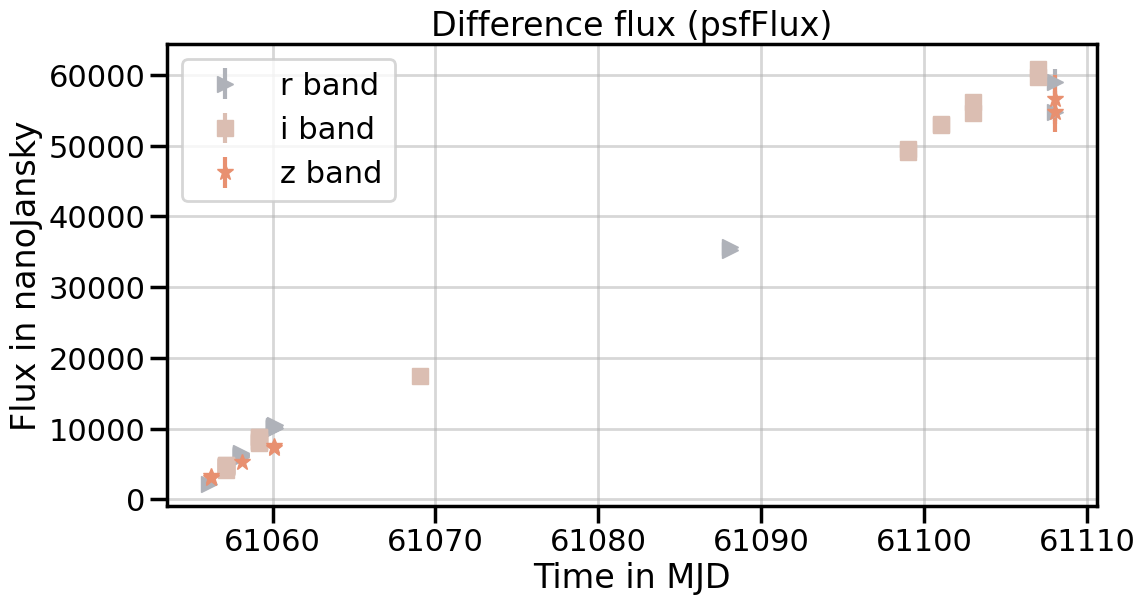

In [6]:
fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))
plot_lightcurve_allbands(
    pdf_obj["r:midpointMjdTai"], 
    pdf_obj["r:psfFlux"], 
    pdf_obj["r:psfFluxErr"], 
    pdf_obj["r:band"], 
    ax=ax,
    label="Difference flux (r band)",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Flux in nanoJansky")
ax.set_xlabel("Time in MJD")
ax.set_title("Difference flux (psfFlux)")
plt.show()

You can substitute `psfFlux` with `scienceFlux` or `templateFlux` to get forced photometry on the science or template image based on `diaSource` positions:

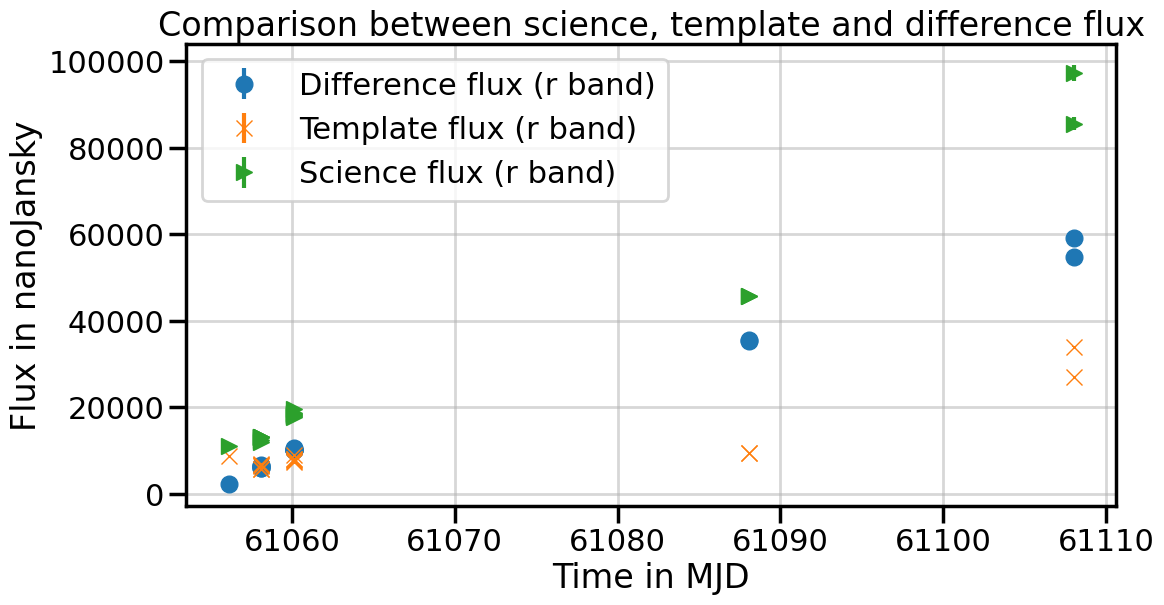

In [7]:
fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))
plot_lightcurve_singleband(
    pdf_obj["r:midpointMjdTai"], 
    pdf_obj["r:psfFlux"], 
    pdf_obj["r:psfFluxErr"], 
    pdf_obj["r:band"], 
    single_band="r",
    ax=ax,
    label="Difference flux (r band)",
    color="C0",
    marker="o",
)
plot_lightcurve_singleband(
    pdf_obj["r:midpointMjdTai"], 
    pdf_obj["r:templateFlux"], 
    pdf_obj["r:templateFluxErr"], 
    pdf_obj["r:band"], 
    single_band="r",
    ax=ax,
    label="Template flux (r band)",
    color="C1",
    marker="x",
)
plot_lightcurve_singleband(
    pdf_obj["r:midpointMjdTai"], 
    pdf_obj["r:scienceFlux"], 
    pdf_obj["r:scienceFluxErr"], 
    pdf_obj["r:band"], 
    single_band="r",
    ax=ax,
    label="Science flux (r band)",
    color="C2",
    marker=">",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Flux in nanoJansky")
ax.set_xlabel("Time in MJD")
ax.set_title("Comparison between science, template and difference flux")
plt.show()

## Forced photometry using diaObject positions

In addition, you can also access flux estimated using forced PSF photometry on the difference (or science) image, based on `diaObject` positions (not `diaSource`):

In [10]:
# get photometry data for 313994139532263447
columns = [
    'r:midpointMjdTai',
    'r:psfFlux',
    'r:psfFluxErr',
    'r:scienceFlux',
    'r:scienceFluxErr',
    'r:band'
]
r = requests.post(
    'https://api.lsst.fink-portal.org/api/v1/fp',
    json={
        'diaObjectId': '313994139532263447',
        'columns': ','.join(columns),
        'output-format': 'json'
    }
)

# Format output in a DataFrame
pdf_forced = pd.read_json(io.BytesIO(r.content))

/tmp/ipykernel_179206/2245878592.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


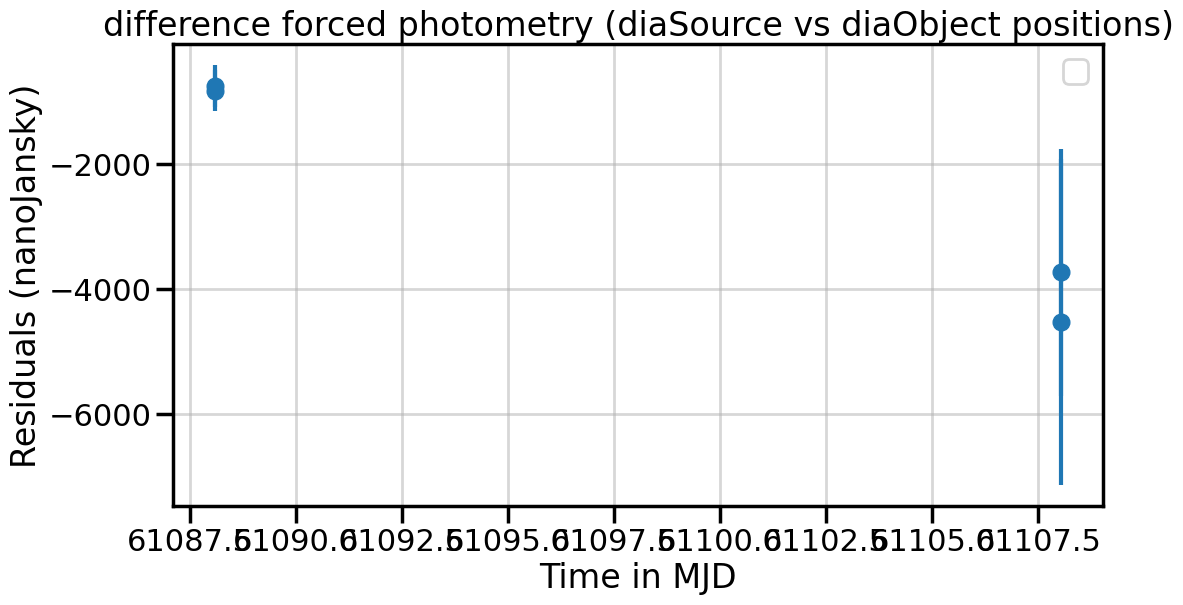

In [11]:
fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))

# align series (less forced photometry point for this object as the project started to stream it later)
mask = pdf_obj["r:midpointMjdTai"] >= pdf_forced["r:midpointMjdTai"].min()
plot_lightcurve_singleband(
    pdf_obj["r:midpointMjdTai"][mask], 
    (pdf_obj["r:psfFlux"][mask] - pdf_forced["r:psfFlux"]), 
    quad_error(pdf_obj["r:psfFluxErr"][mask], pdf_forced["r:psfFluxErr"]), 
    pdf_obj["r:band"][mask], 
    single_band="r",
    ax=ax,
    label=None,
    color="C0",
    marker="o",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Residuals (nanoJansky)")
ax.set_xlabel("Time in MJD")
ax.set_title("difference forced photometry (diaSource vs diaObject positions)")
plt.show()

/tmp/ipykernel_179206/780321408.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


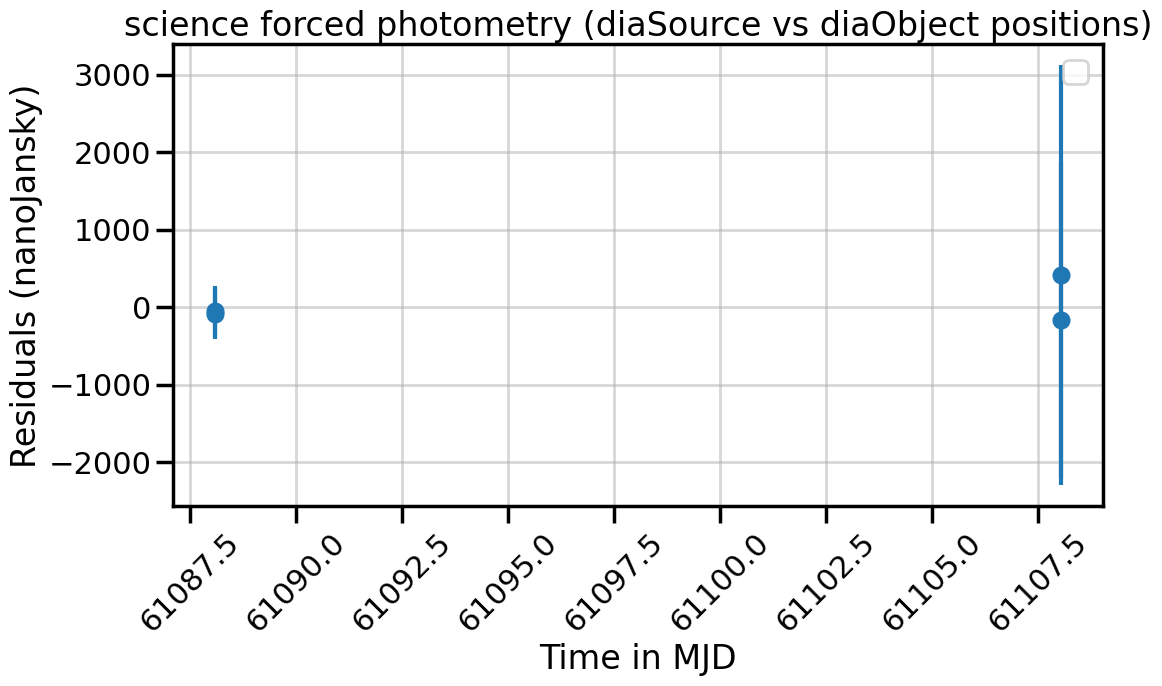

In [12]:
fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(12, 6))

# align series (less forced photometry point for this object as the project started to stream it later)
mask = pdf_obj["r:midpointMjdTai"] >= pdf_forced["r:midpointMjdTai"].min()
plot_lightcurve_singleband(
    pdf_obj["r:midpointMjdTai"][mask], 
    (pdf_obj["r:scienceFlux"][mask] - pdf_forced["r:scienceFlux"]), 
    quad_error(pdf_obj["r:scienceFluxErr"][mask], pdf_forced["r:scienceFluxErr"]), 
    pdf_obj["r:band"][mask], 
    single_band="r",
    ax=ax,
    label=None,
    color="C0",
    marker="o",
)

ax.grid(alpha=0.5)
ax.legend()
ax.set_ylabel("Residuals (nanoJansky)")
ax.set_xlabel("Time in MJD")
# ax.set_xticklabels([], rotation=45)
ax.set_title("science forced photometry (diaSource vs diaObject positions)")
ax.tick_params(axis='x', labelrotation=45)
plt.show()

Note that the forced photometry was available late in Rubin alert packet, hence for this source, there is less forced photometry measurements than photometry.